## Purpose:
Train and evaluate an XGBoost classifier to predict in-hospital mortality for ICU patients using SQL-engineered features from the MIMIC-III demo dataset. This notebook serves as the  proof-of-concept for Track 1 from raw database query to a trained, explainable ML model.

## Context:
The MIMIC-III demo contains ~100 ICU stays with a high mortality rate relative to the full dataset, creating a significant class imbalance. Standard accuracy metrics are misleading under these conditions, so this notebook uses AUROC as the primary evaluation metric and applies scale_pos_weight in XGBoost to compensate for the skewed class distribution.
All features are pulled directly from the SQL views built in sql/features.sql via tracks/sql_features.py — no feature engineering happens inside this notebook. The notebook's job is purely modeling: load features, handle imbalance, train, evaluate, and explain.
This notebook is intentionally scoped to the demo dataset as a pipeline prototype. Results should be interpreted as proof-of-concept only — production-quality performance requires the full MIMIC-III dataset (~46,000 ICU stays).

# Section 1 Imports

In [36]:
# Data handling
import pandas as pd
import numpy as np 

# Database
import sqlite3

# Model 
from xgboost import XGBClassifier

# Class imbalance 
from imblearn.over_sampling import SMOTE

# Sklearn utilities 
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import StandardScaler

# Explainability 
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Extras 
import warnings
from pathlib import Path
from scipy.stats import gaussian_kde

# Section 2 Configuration 

In [2]:
# -- Setup path to mimic.db --
DB_PATH = Path("../db/mimic.db")

# -- Define target column --
TARGET = "died_in_hospital"

# -- Setup Random seeds for Reproducibility --
SEED = 42 
np.random.seed(SEED)

# -- Class Imbalance Placeholder --
SCALE_POS_WEIGHT = None 

# -- Supress any warnings --
warnings.filterwarnings("ignore")

# -- Plot Style -- 
sns.set_style("whitegrid")

# -- Sanity Check -- 
assert DB_PATH.exists(), f"Database not found at {DB_PATH}"
print(f"✅ Database found: {DB_PATH}")

✅ Database found: ..\db\mimic.db


# Section 3 Loading Features from the Database

In [3]:
# Connect to Database 
conn = sqlite3.connect(DB_PATH)

# Execute SQL file to create views in mimic.db
with open("../sql/features.sql") as f:
    sql = f.read()
conn.executescript(sql)

# Query the features from the databse 
v_features = pd.read_sql("SELECT * FROM v_features", conn)

# Query v_features view into a DataFrame
df = pd.read_sql("SELECT * FROM v_features", conn)

# Close connection
conn.close()

# Sanity checks
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (136, 89)
Columns: ['subject_id', 'hadm_id', 'icustay_id', 'gender', 'admission_type', 'insurance', 'ethnicity', 'dob', 'dod', 'intime', 'outtime', 'admittime', 'dischtime', 'icu_los_hours', 'hosp_los_days', 'age_at_admit', 'died_in_hospital', 'hr_mean_24h', 'hr_min_24h', 'hr_max_24h', 'sbp_mean_24h', 'sbp_min_24h', 'sbp_max_24h', 'spo2_mean_24h', 'spo2_min_24h', 'spo2_max_24h', 'resp_mean_24h', 'resp_min_24h', 'resp_max_24h', 'temp_mean_24h', 'temp_min_24h', 'temp_max_24h', 'gcs_mean_24h', 'gcs_min_24h', 'gcs_max_24h', 'n_vital_measurements_24h', 'hematocrit_mean_24h', 'hematocrit_min_24h', 'potassium_mean_24h', 'potassium_min_24h', 'potassium_max_24h', 'sodium_mean_24h', 'sodium_min_24h', 'sodium_max_24h', 'creatinine_mean_24h', 'creatinine_max_24h', 'chloride_mean_24h', 'bun_mean_24h', 'bun_max_24h', 'bicarb_mean_24h', 'bicarb_min_24h', 'anion_gap_mean_24h', 'anion_gap_max_24h', 'glucose_mean_24h', 'glucose_min_24h', 'glucose_max_24h', 'platelets_mean_24h', 'platelets_min_24h

,subject_id,hadm_id,icustay_id,gender,admission_type,insurance,ethnicity,dob,dod,intime,...,has_chf,has_diabetes,has_resp_failure,has_sepsis,has_anemia,has_cad,has_acidosis,n_diagnoses,n_prior_admissions,vasopressor_flag
0,10006,142345,206504,F,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,2094-03-05,2165-08-12,2164-10-23 21:10:15,...,1,1,0,0,1,1,0,21,0,0
1,10011,105331,232110,F,EMERGENCY,Private,UNKNOWN/NOT SPECIFIED,2090-06-05,2126-08-28,2126-08-14 22:34:00,...,0,0,0,0,0,0,0,6,0,0
2,10013,165520,264446,F,EMERGENCY,Medicare,UNKNOWN/NOT SPECIFIED,2038-09-03,2125-10-07,2125-10-04 23:38:00,...,0,0,0,1,0,0,0,9,0,1
3,10017,199207,204881,F,EMERGENCY,Medicare,WHITE,2075-09-21,2152-09-12,2149-05-29 18:52:29,...,0,1,0,0,1,0,0,14,0,0
4,10019,177759,228977,M,EMERGENCY,Medicare,WHITE,2114-06-20,2163-05-15,2163-05-14 20:43:56,...,0,0,1,1,0,0,0,14,0,1


# Section 04 EDA

The goal is to understand your data before modeling, especially around the class imbalance issue in the Demo of MIMIC 3. 

**Part 1 — Class balance**
This is the most important thing to look at given what we know. We want to see how many patients died vs survived.

**Part 2 — Missing values**
XGBoost handles NaNs natively but we still want to know how many nulls exist per column.

**Part 3 — Feature distributions**
Pick a few clinically meaningful features from what you know about v_features — things like age_at_admit, icu_los_hours, creatinine_max_24h.

**Part 4 — Compute SCALE_POS_WEIGHT**


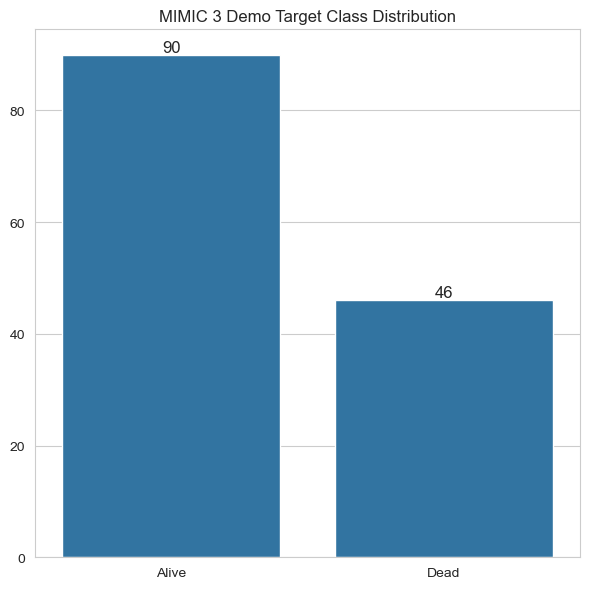

In [4]:
# Part 1


# -- View our class imbalance --
# Obtain counts of classes
target_counts = df['died_in_hospital'].value_counts()

# Store counts in a dictionary 
target_dist = {'Alive': target_counts.get(0), 'Dead': target_counts.get(1)}

# -- Create Visualization of class imablance as a barchart --
plt.figure(figsize=(6,6), facecolor='white') # Make Figure
ax = sns.barplot(target_dist) # Plot the bar chart
for bar in ax.patches:
    ax.annotate(
        str(int(bar.get_height())),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title("MIMIC 3 Demo Target Class Distribution")
plt.tight_layout()
plt.show()

Columns with nulls: 59 / 89
hr_mean_24h                  4
hr_min_24h                   4
hr_max_24h                   4
sbp_mean_24h                32
sbp_min_24h                 32
sbp_max_24h                 32
spo2_mean_24h                4
spo2_min_24h                 4
spo2_max_24h                 4
resp_mean_24h                4
resp_min_24h                 4
resp_max_24h                 4
temp_mean_24h                7
temp_min_24h                 7
temp_max_24h                 7
gcs_mean_24h                 4
gcs_min_24h                  4
gcs_max_24h                  4
n_vital_measurements_24h     4
hematocrit_mean_24h          5
hematocrit_min_24h           5
potassium_mean_24h           3
potassium_min_24h            3
potassium_max_24h            3
sodium_mean_24h              3
sodium_min_24h               3
sodium_max_24h               3
creatinine_mean_24h          4
creatinine_max_24h           4
chloride_mean_24h            4
bun_mean_24h                 5
bun_max_24h

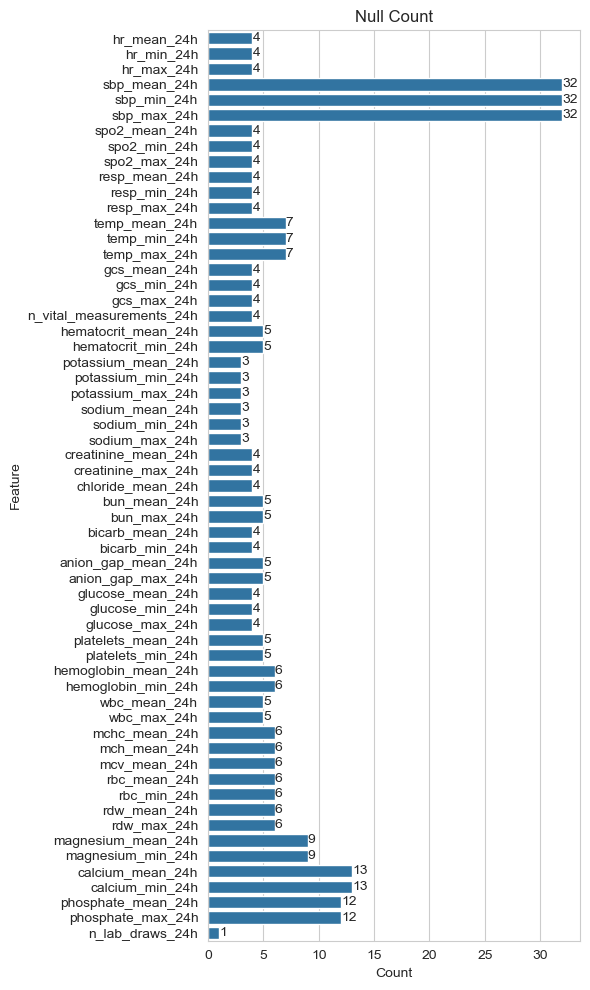

In [16]:
# Part 2

# -- Determine the null count for each column 
null_counts = df.isnull().sum().rename('null_count')
null_counts = null_counts[null_counts > 0] # Filter where we do have nulls

print(f"Columns with nulls: {len(null_counts)} / {df.shape[1]}")
print(null_counts)

if len(null_counts) == 0:
    print("✅ No null values found")
else:
    # Visualize the nulls 
    plt.figure(figsize=(6, 10), facecolor='white')
    ax = sns.barplot(x=null_counts.values, y=null_counts.index, orient='h')
    
    for bar in ax.patches:
        ax.annotate(
            str(int(bar.get_width())), # The count
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            ha='left',
            va='center',
            fontsize=10
        )

    plt.title("Null Count")
    plt.ylabel("Feature")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

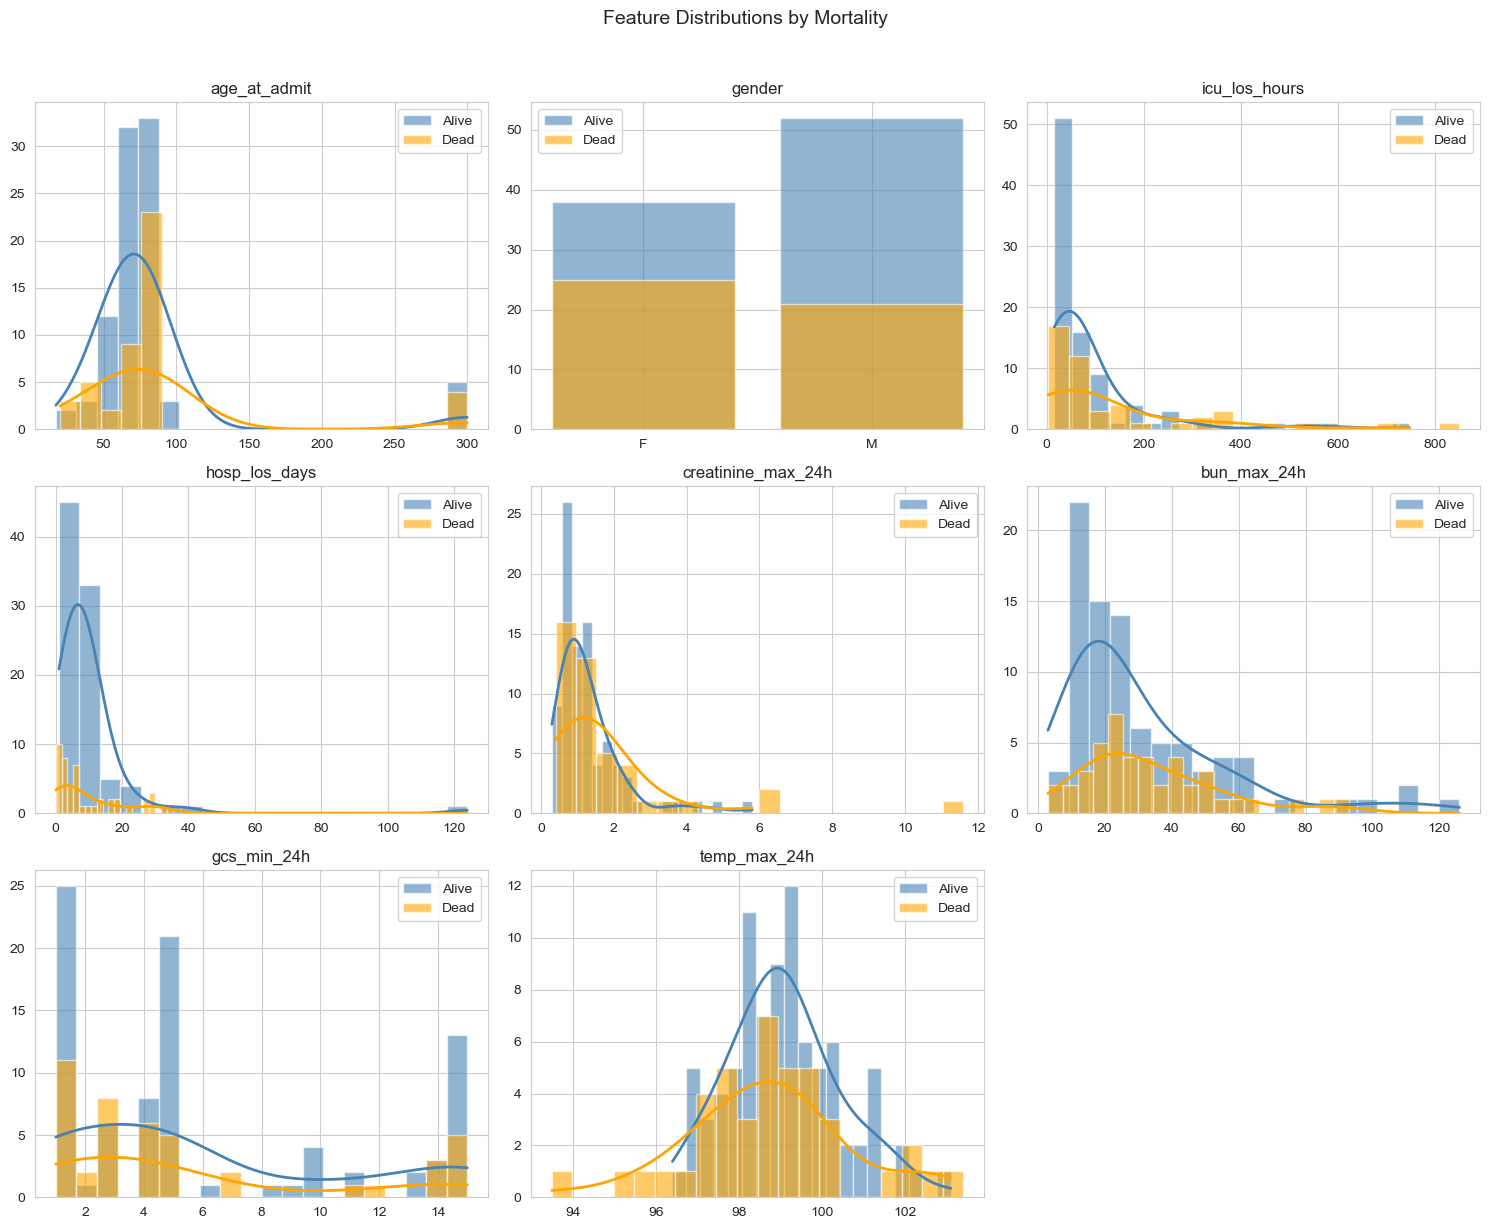

In [39]:
# Part 3 

# There are many features to plot but some features that can potentially tell a good story are kidney failure features. 
# In addition to this demographics also plays a major role
features_to_plot = [
    # -- Demographics --
    "age_at_admit", # Tell us patient age
    "gender", # Tells us patient gender
    
    # -- ICU Stay --
    "icu_los_hours", # ICU Stay in hours
    "hosp_los_days", # Total hospital stay
    
    # -- Lab Values -- 
    "creatinine_max_24h", # high creatinine signals kidney failure, strongly tied to mortality
    #"lactate_max_24h", # elevated lactate indicates poor oxygen delivery, a key sepsis marker
    "bun_max_24h", # blood urea nitrogen, another kidney function marker
    
    # -- Vital Signs -- 
    "gcs_min_24h", # Glasgow Coma Scale minimum, low scores mean reduced consciousness, highly predictive of death
    "temp_max_24h", # ever can indicate infection
]

df_plot = df.dropna(subset=['died_in_hospital']) 
df_plot['died_in_hospital'] = df_plot['died_in_hospital'].astype(int)

# -- Create plot grid --
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
# Iterate on desired features to plot 
for i, feature in enumerate(features_to_plot):
    df_clean = df_plot.dropna(subset=[feature])
    
    alive = df_clean[df_clean['died_in_hospital'] == 0]
    dead  = df_clean[df_clean['died_in_hospital'] == 1]
    
    ax = axes[i]
    
    if feature == 'gender':
        ax.bar(['F', 'M'], 
                [alive[feature].value_counts().get('F', 0), 
                alive[feature].value_counts().get('M', 0)], 
                alpha=0.6, label='Alive', color='steelblue')
        ax.bar(['F', 'M'], 
                [dead[feature].value_counts().get('F', 0), 
                dead[feature].value_counts().get('M', 0)], 
                alpha=0.6, label='Dead', color='orange')
    else:
        ax.hist(alive[feature], alpha=0.6, label='Alive', color='steelblue', bins=20)
        ax.hist(dead[feature],  alpha=0.6, label='Dead',  color='orange',    bins=20)
        # -- KDE --
        # Get the data for one class
        values_alive = alive[feature].dropna()
        values_dead = dead[feature].dropna()
        
        # Create KDE object
        kde_alive = gaussian_kde(values_alive)
        kde_dead = gaussian_kde(values_dead)
        
        # Create a range of x values spanning the data
        x_range_alive = np.linspace(values_alive.min(), values_alive.max(), 200)
        x_range_dead = np.linspace(values_dead.min(), values_alive.max(), 200)
        
        # Scale the KDE to match histogram counts
        ax.plot(x_range_alive, kde_alive(x_range_alive) * len(values_alive) * (values_alive.max() - values_alive.min()) / 20, 
                color='steelblue', linewidth=2)
        ax.plot(x_range_dead, kde_dead(x_range_dead) * len(values_dead) * (values_dead.max() - values_dead.min()) / 20, 
                color='orange', linewidth=2)
    ax.set_title(feature)
    ax.legend()

for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Mortality", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Clinical interpretation of each plot:

`age_at_admit`
Alive patients peak around 60-70 years. Dead patients spread further right toward 80-90+. Older patients have less physiological reserve fewer functional organs, more comorbidities, less ability to recover from critical illness. Age is one of the strongest predictors of ICU mortality.

`gcs_min_24h`
This one spreads left not right because, lower GCS is worse. Dead patients cluster at 2-4 (deeply unconscious, unresponsive) while alive patients peak at 14-15 (fully alert). GCS below 8 is clinically defined as a coma. This is likely a strong predictor for XGBoost.

`creatinine_max_24h`
Dead patients have a longer right tail beyond 4-6 mg/dL. Normal creatinine is 0.6-1.2 mg/dL. Severely elevated creatinine means the kidneys are failing and the body can't filter waste products, toxins accumulate, and multi-organ failure follows.

`bun_max_24h`
Similar story to creatinine where dead patients spread further right beyond 40-60 mg/dL. Normal BUN is 7-20 mg/dL. When both BUN and creatinine are elevated together it strongly suggests acute kidney injury which dramatically increases mortality risk.

`icu_los_hours`
This is the counterintuitive one. You might expect sicker patients who die to spend more time in the ICU — but the plot shows dead patients actually have shorter stays. Why? 

Two reasons Susppected Reasons:
Patients who die often deteriorate and pass away quickly, within the first 24-48 hours
Patients who survive long enough to recover naturally accumulate more ICU hours

`hosp_los_days`
Same story as ICU hours but at the hospital level. Dead patients cluster in the first 1-20 days. Survivors spread further right because they stay longer recovering before discharge.

`temp_max_24h`
Dead patients orange curve shifts slightly right toward higher temperatures. Fever above 38.3°C (101°F) indicates systemic infection, both strongly associated with ICU mortality. The separation here is subtle though. Temperature will most likely be a weak predictor compared to GCS or creatinine.

`gender`
Hard to draw strong conclusions from this plot alone. Males appear in higher numbers overall in both groups, which likely reflects the general ICU population demographics rather than gender being a strong mortality predictor. You'd need a normalized proportion chart to see a real gender effect.

**The big picture for XGBoost:**
Your strongest suspected predictors in this order:

gcs_min_24h — clearest separation
creatinine_max_24h — strong right tail
bun_max_24h — kidney failure signal
age_at_admit — consistent rightward shift
temp_max_24h — subtle but present
icu_los_hours — present but counterintuitive
gender — weakest signal

In [ ]:
# Part 4 

# We can see it concretly
for key, value in target_dist.items():
    print(f"{key}: {value}")

# View imbalance ratio 
imb_ratio = np.round(target_dist['Alive'] / target_dist['Dead'], 2)
print(f"Imbalance Ratio: {imb_ratio}x")

# Update the SCALE_POS_WEIGHT
SCALE_POS_WEIGHT = target_dist['Alive'] / target_dist['Dead']
print(f"scale_pos_weight set to: {SCALE_POS_WEIGHT:.2f}")

Alive: 90
Dead: 46
Imbalance Ratio: 1.96x
scale_pos_weight set to: 1.96
